In [7]:
import os
import sys
p = os.path.abspath('../..')
if p not in sys.path:
    sys.path.append(p)
import waveorder as wo
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
from numcodecs import Blosc
import glob
import json
from waveorder.visual import plotVectorField
import zarr
from recOrder.recOrder.compute.QLIPP_compute import reconstruct_QLIPP_3D, initialize_reconstructor
from recOrder.recOrder.io.reader import MicromanagerReader

In [12]:
path = '/gpfs/CompMicro/rawdata/hummingbird/Janie/2021_02_03_40x_04NA_A549/48hr_RSV/Coverslip_2/C1_C2_multichannel_stack_1/'

tiff_paths = glob.glob(path+'*.tif')
tiff_paths.sort()


In [ ]:
new = tiff.TiffFile('/gpfs/CompMicro/rawdata/hummingbird/Janie/2021_03_05_40x_04NA_A549 phalloidin/RSV48/_1/_1_MMStack.ome.tif')
old = tiff.TiffFile('/gpfs/CompMicro/rawdata/hummingbird/Janie/2021_02_25_40X_04NA_A549/MOCK_IFNA_24/_1/_1_MMStack.ome.tif')

In [101]:
test = tiff.imread('/gpfs/CompMicro/rawdata/hummingbird/Janie/SiR_actin A549/Mock24 bleach_1/Mock24 bleach_1_MMStack.ome.tif', aszarr=True)

In [102]:
np.shape(test)

(2,)

In [112]:
test._data

In [115]:
test2 = MicromanagerReader('/gpfs/CompMicro/rawdata/hummingbird/Janie/SiR_actin A549/Mock24 bleach_1', extract_data=True)

In [116]:
test2._positions

{0: <zarr.core.Array (3, 65, 2048, 2048) uint16 read-only>}

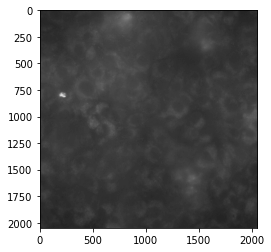

In [127]:
plt.imshow(test2._positions[0][0][10], 'gray')

In [69]:
state0_2 = data2._positions[0][0]

In [70]:
state0 = data._positions[0][0]

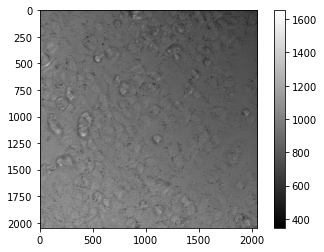

In [89]:
plt.imshow(state0_2[32], 'gray')
plt.colorbar()

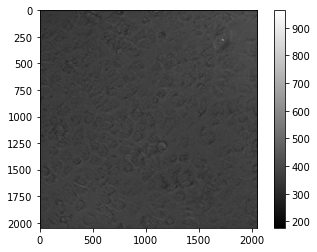

In [87]:
plt.imshow(state0[32], 'gray')
plt.colorbar()

In [90]:
test[0][32] - state0[32]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint16)

In [91]:
np.max(test[0][32] - state0[32])

0

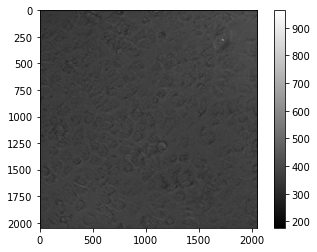

In [88]:
plt.imshow(test[0][32], 'gray')
plt.colorbar()

In [84]:
test = tiff.imread('/gpfs/CompMicro/rawdata/hummingbird/Janie/2021_03_05_40x_04NA_A549 phalloidin/RSV48/_1/_1_MMStack.ome.tif')

In [85]:
np.shape(test)

(6, 65, 2048, 2048)

In [16]:
%%time
bg_path = '/gpfs/CompMicro/rawdata/hummingbird/Janie/2021_02_03_40x_04NA_A549/48hr_RSV/BG/'
bg_data = load_bg(bg_path, 2048, 2448)

CPU times: user 31.2 ms, sys: 60.6 ms, total: 91.8 ms
Wall time: 2.02 s


In [17]:
%%time
# zarr_store = init_zarr_store(save_dir+'48hr_RSV')

    ret_stack, ori_stack, BF_stack, phase3D = reconstruct_QLIPP_3D(positions[pos],
                                                           bg_data, reconstructor, method = "Tikhonov",
                                                           reg_re = 1e-4, reg_im = 1e-4, rho = 1e-5, 
                                                           lambda_re = 1e-3, lambda_im = 1e-3, itr = 20)


Computing Birefringence...
Finished Computing Birefringence (1.88 min)
Computing 3d Phase...
Finished Reconstruction (2.49 min)

Computing Birefringence...
Finished Computing Birefringence (1.88 min)
Computing 3d Phase...
Finished Reconstruction (2.40 min)

Computing Birefringence...
Finished Computing Birefringence (1.88 min)
Computing 3d Phase...
Finished Reconstruction (2.40 min)

Computing Birefringence...
Finished Computing Birefringence (1.88 min)
Computing 3d Phase...
Finished Reconstruction (2.41 min)

Computing Birefringence...
Finished Computing Birefringence (1.88 min)
Computing 3d Phase...
Finished Reconstruction (2.40 min)

CPU times: user 12min 34s, sys: 8min 21s, total: 20min 55s
Wall time: 15min 51s


In [ ]:
wo.visual.image_stack_viewer_fast(retardance_stack, vrange=(0,20))

In [ ]:
wo.visual.image_stack_viewer_fast(np.transpose(phase3d,(2,1,0)))

In [ ]:
plt.figure(dpi=300)
plt.imshow(phase3d[:,:,30], 'gray')